# Multi-Object Detection & Persistent ID Tracking
**YOLOv8 + ByteTrack | Sports / Event Footage**

This notebook walks through the complete pipeline:
1. Environment setup
2. Video selection
3. Detection + tracking
4. Analytics (heatmap, count chart, speed)
5. Result inspection

## 0 · Install dependencies

In [1]:
# Run once
!pip install ultralytics yt-dlp opencv-python-headless numpy --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\LSE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1 · Download a public sports video
We use **yt-dlp** to fetch a YouTube video in low resolution for speed. 
Replace the URL with any publicly available video.


In [2]:
import subprocess, os

# ─── Change this URL to your chosen public video ───────────────────────────
VIDEO_URL = "https://www.youtube.com/watch?v=tWU8CXFLOgk"  # replace with real URL
# ───────────────────────────────────────────────────────────────────────────

INPUT_PATH  = "input_video.mp4"
OUTPUT_PATH = "outputs/tracked.mp4"
os.makedirs("outputs", exist_ok=True)

if not os.path.exists(INPUT_PATH):
    subprocess.run([
        "yt-dlp",
        "-f", "bestvideo[height<=480][ext=mp4]+bestaudio/best[height<=480]",
        "--merge-output-format", "mp4",
        "-o", INPUT_PATH,
        VIDEO_URL
    ], check=True)
    print("Downloaded:", INPUT_PATH)
else:
    print("Video already present:", INPUT_PATH)

Downloaded: input_video.mp4


## 2 · Import pipeline

In [3]:
import sys
sys.path.insert(0, "src")

from tracker  import SportTracker
from analytics import (
    generate_heatmap,
    plot_object_count,
    estimate_speeds,
    build_metrics_text,
)
import cv2, numpy as np
from IPython.display import Image as IPImage, display

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\LSE\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3 · Initialise tracker
| Parameter | Recommended range | Notes |
|-----------|-------------------|-------|
| `model_path` | `yolov8n.pt` – `yolov8x.pt` | Larger = slower but more accurate |
| `conf_thresh` | 0.25 – 0.50 | Lower → more detections (more FP) |
| `frame_skip` | 1 – 3 | 1 = every frame (slowest, best IDs) |

In [4]:
tracker = SportTracker(
    model_path  = "yolov8m.pt",   # auto-downloaded on first run
    conf_thresh = 0.35,
    iou_thresh  = 0.45,
    classes     = [0],             # 0 = person
    frame_skip  = 2,
    draw_traj   = True,
    device      = "cpu",           # change to 'cuda' if GPU available
)

[INFO] Loading model: yolov8m.pt  device=cpu


## 4 · Run the pipeline

In [7]:
stats = tracker.process_video(
    input_path  = INPUT_PATH,
    output_path = OUTPUT_PATH,
    max_frames  = None,   # set e.g. 300 for a quick test
)
print(stats)

[INFO] Input : input_video.mp4
[INFO] Resolution: 854x480  FPS: 25.0  Frames: 1022
[INFO] Output: outputs/tracked.mp4
  frame    99 | written    50 | active   2 | total IDs  35
  frame   199 | written   100 | active   3 | total IDs  59
  frame   299 | written   150 | active   2 | total IDs  66
  frame   399 | written   200 | active   0 | total IDs  71
  frame   499 | written   250 | active   3 | total IDs  86
  frame   599 | written   300 | active   6 | total IDs 108
  frame   699 | written   350 | active   7 | total IDs 125
  frame   799 | written   400 | active   9 | total IDs 138
  frame   899 | written   450 | active   1 | total IDs 149
  frame   999 | written   500 | active   1 | total IDs 166

[DONE] Summary:
  frames_processed: 511
  elapsed_seconds: 368.86
  avg_proc_fps: 1.39
  total_unique_ids: 167
  avg_active_per_frame: 2.99
  max_active_per_frame: 10
{'frames_processed': 511, 'elapsed_seconds': 368.86, 'avg_proc_fps': 1.39, 'total_unique_ids': 167, 'avg_active_per_frame': 

## 5 · Movement heatmap

[analytics] Heatmap saved → outputs/heatmap.png


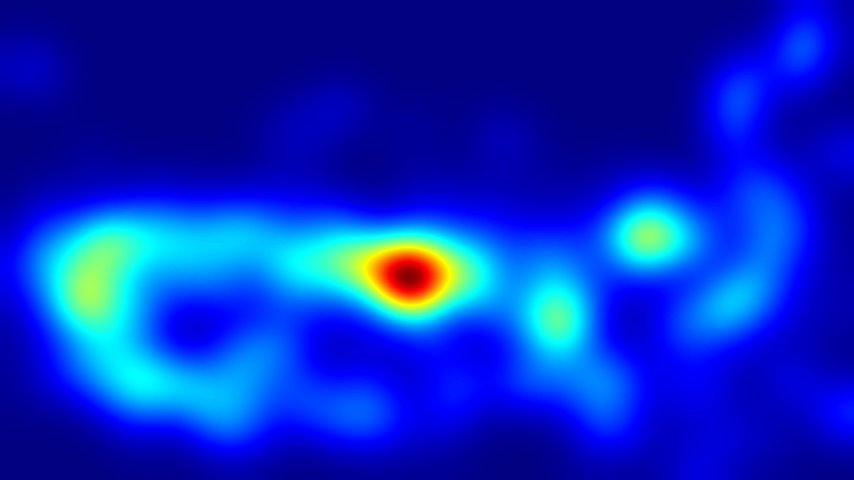

In [8]:
cap = cv2.VideoCapture(INPUT_PATH)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.release()

hm = generate_heatmap(tracker.tracks, (W, H), "outputs/heatmap.png")
display(IPImage("outputs/heatmap.png", width=640))

## 6 · Object count over time

[analytics] Object count chart saved → outputs/object_count.png


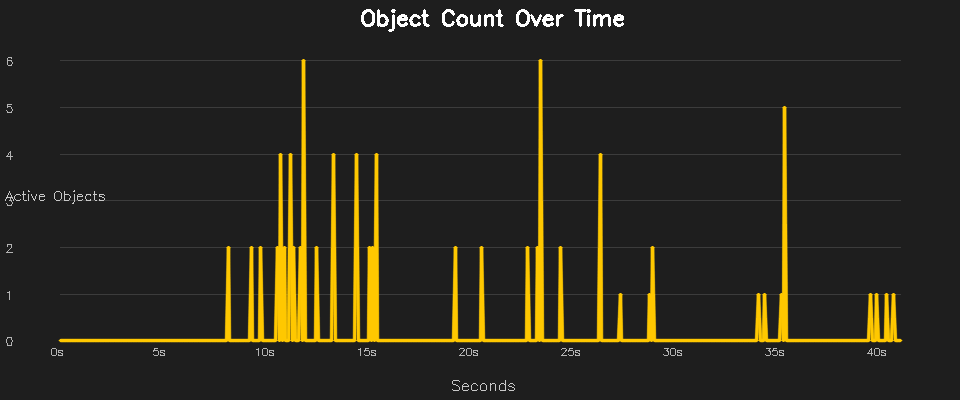

In [9]:
active_counts = [
    len([t for t in tracker.tracks.values() if t.frame_last_seen == fi])
    for fi in range(stats["frames_processed"])
]
plot_object_count(active_counts, fps=fps, frame_skip=tracker.frame_skip)
display(IPImage("outputs/object_count.png", width=640))

## 7 · Speed estimates

In [10]:
speeds = estimate_speeds(
    tracker.tracks, fps=fps,
    frame_skip=tracker.frame_skip,
    pixels_per_meter=30.0,   # tune to your video's real-world scale
)
print(build_metrics_text(stats, speeds, video_source=VIDEO_URL))

  TRACKING METRICS REPORT
  Video source     : https://www.youtube.com/watch?v=tWU8CXFLOgk
  Frames processed : 511
  Processing time  : 368.86 s
  Avg proc FPS     : 1.39
  Total unique IDs : 167
  Avg active/frame : 2.99
  Max active/frame : 10

  Per-track speed estimates (m/s approx.):
    ID   1: 9.94 m/s  (~35.8 km/h)
    ID   2: 0.30 m/s  (~1.1 km/h)
    ID   3: 1.63 m/s  (~5.9 km/h)
    ID   4: 1.49 m/s  (~5.4 km/h)
    ID   5: 2.00 m/s  (~7.2 km/h)
    ID   7: 4.93 m/s  (~17.7 km/h)
    ID  13: 13.44 m/s  (~48.4 km/h)
    ID  14: 1.65 m/s  (~5.9 km/h)
    ID  15: 2.90 m/s  (~10.4 km/h)
    ID  16: 6.10 m/s  (~22.0 km/h)
    ID  17: 8.79 m/s  (~31.6 km/h)
    ID  21: 16.04 m/s  (~57.7 km/h)
    ID  22: 3.65 m/s  (~13.1 km/h)
    ID  23: 0.85 m/s  (~3.1 km/h)
    ID  25: 4.36 m/s  (~15.7 km/h)
    ID  29: 0.75 m/s  (~2.7 km/h)
    ID  31: 0.34 m/s  (~1.2 km/h)
    ID  37: 5.17 m/s  (~18.6 km/h)
    ID  38: 2.67 m/s  (~9.6 km/h)
    ID  39: 2.85 m/s  (~10.3 km/h)
    ID  41: 2.36

## 8 · Inspect individual tracks

In [13]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.8 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.8 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.8 MB 5.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.8 MB 5.8 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.8 MB 6.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 5.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.8 MB 5.1 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.8 MB 4.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 4.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\LSE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
rows = []
for tid, ts in tracker.tracks.items():
    rows.append({
        "ID": tid,
        "first_frame": ts.frame_first_seen,
        "last_frame":  ts.frame_last_seen,
        "duration_frames": ts.frame_last_seen - ts.frame_first_seen + 1,
        "total_px_travel": round(ts.total_distance, 1),
        "speed_m_s": speeds.get(tid, 0),
    })
df = pd.DataFrame(rows).sort_values("ID")
df

,ID,first_frame,last_frame,duration_frames,total_px_travel,speed_m_s
0,1,10,328,319,1431.9,9.94
1,2,64,102,39,14.4,0.30
2,3,106,140,35,62.4,1.63
3,4,106,142,37,64.6,1.49
4,5,106,148,43,91.4,2.00
...,...,...,...,...,...,...
162,452,932,940,9,42.5,4.43
163,453,944,986,43,138.5,2.62
164,454,944,944,1,0.0,0.00
165,456,976,996,21,104.5,6.22
